# Eerste stappen met Python
Klik op een codeblok en druk op **Shift + Enter** om het uit te voeren. Werk van boven naar beneden. Kies rechtsboven bij **Select Kernel** de Python-omgeving **.venv**.
Een notebook bestaat uit tekstblokken zoals dit en uitvoerbare codeblokken. Het originele CSV-bestand wordt hier alleen gelezen.

## 1. Probeer Python
Voer de volgende cel uit. Onder de cel verschijnt een begroeting.

In [103]:
print('Python werkt!')

Python werkt!


## 2. Lees de dataset
pandas is een hulpmiddel voor tabellen. We noemen het kortweg pd. De ingelezen tabel geven we de naam data. head() toont de eerste vijf rijen. We tonen alleen enkele onderzoekskolommen.

In [104]:
import pandas as pd

data = pd.read_csv('../data/Heart faillure prediction data.csv')
data[['Age', 'Sex', 'Cholesterol', 'HeartDisease']].head()

,Age,Sex,Cholesterol,HeartDisease
0,40.0,M,289,0
1,49.0,F,180,1
2,37.0,M,283,0
3,48.0,F,214,1
4,54.0,M,195,0


## 3. Hoe groot is de tabel?
shape geeft het aantal rijen en kolommen. Verwacht: (918, 15).

In [105]:
data.shape

(918, 15)

## 4. Ontbreekt er iets?
isna() zoekt lege waarden. sum() telt ze per kolom. Bij welke kolom zie je een getal groter dan nul? Let op: een nul of afwijkende tekst wordt hiermee niet automatisch als ontbrekend herkend.

In [106]:
data.isna().sum()

CaseNumber        0
LastName          0
PostCode          0
Age               3
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Bevindingen ontbrekende waarden

Bij 3 van de 918 rijen ontbreekt de leeftijd. De overige kolommen bevatten volgens isna() geen ontbrekende waarden. Deze controle herkent nullen of afwijkende tekst niet automatisch als ontbrekende metingen.

## 5. Bekijk de uitkomstkolom
value_counts() telt hoe vaak elke waarde voorkomt. Volgens de opdracht horen hier 0 en 1 te staan. Welke extra waarde zie je? We wijzigen nog niets: eerst onderzoeken wat die waarde betekent.

In [107]:
data['HeartDisease'].value_counts(dropna=False)

HeartDisease
1      501
0      410
yes      7
Name: count, dtype: int64

## Bevindingen uitkomstkolom

HeartDisease bevat 410 keer `0`, 501 keer `1` en 7 keer `yes`. Volgens de attribuutinformatie zijn de bedoelde codes 0 (geen hartaandoening) en 1 (wel een hartaandoening). Er is dus inconsistente codering. Dat `yes` hetzelfde betekent als `1` is een aanname die we eerst bij de bron of docent moeten controleren. We passen de waarden nog niet aan.

In [108]:
data["Age"].describe()

count    915.000000
mean      53.512568
std        9.448039
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

## Bevindingen leeftijd

Hiermee krijg je onder andere:
- count: het aantal ingevulde leeftijden.
- mean: de gemiddelde leeftijd.
- min en max: de laagste en hoogste leeftijd.
- 50%: de middelste leeftijd, oftewel de mediaan.

Die percentages geven aan onder welke leeftijd een bepaald deel van de patiënten valt. Ze heten kwartielen. Python gebruikt hiervoor de ingevulde leeftijden, gesorteerd van laag naar hoog.
- 25% — eerste kwartiel: ongeveer een kwart van de patiënten heeft deze leeftijd of is jonger.
- 50% — mediaan: ongeveer de helft heeft deze leeftijd of is jonger. Dit is de middelste waarde, niet het gemiddelde.
- 75% — derde kwartiel: ongeveer driekwart heeft deze leeftijd of is jonger. Een kwart is ouder.


De minimale leeftijd is 28 en de maximale leeftijd is 77.
Van 915 patiënten is de leeftijd ingevuld; bij 3 ontbreekt deze.
De gemiddelde leeftijd is 53,5 jaar en de mediaan 54 jaar.
De middelste 50% van de leeftijden ligt tussen 47 en 60 jaar.

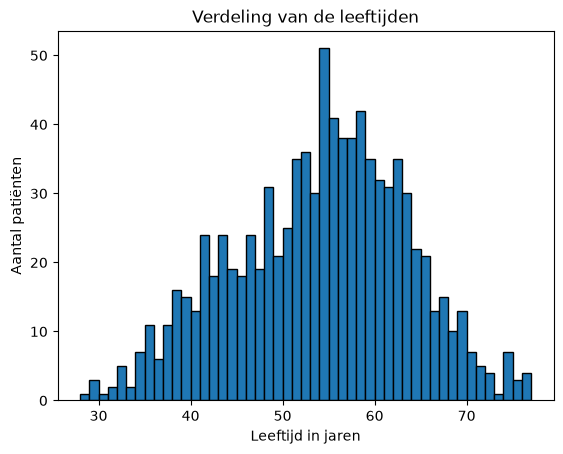

In [109]:
import matplotlib.pyplot as plt

data["Age"].plot.hist(bins=49, edgecolor="black")

plt.title("Verdeling van de leeftijden")
plt.xlabel("Leeftijd in jaren")
plt.ylabel("Aantal patiënten")
plt.show()


## bevindingen histogram

De meest voorkomende leeftijd in de dataset is 54 jaar. Deze leeftijd komt bij 51 patiënten voor. Het histogram toont alle patiënten, ongeacht of zij volgens de dataset een hartaandoening hebben.


In [110]:
metingen = [
    "Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"
]

data[metingen].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,915.000000,918.000000,918.000000,918.000000,918.000000
mean,53.512568,131.882353,198.799564,136.809368,0.887364
std,9.448039,21.881591,109.384145,25.460334,1.066570
min,28.000000,-126.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


## Bevindingen numerieke metingen

De minimumwaarde van RestingBP is -126. Deze negatieve waarde is verdacht en vraagt om controle van de oorspronkelijke registratie. We veranderen deze niet zonder onderbouwing naar +126. Ook opvallend hoge of lage waarden in de andere kolommen zijn aanleiding voor onderzoek; een uitschieter is niet automatisch een fout.

In [111]:
data[["RestingBP", "Cholesterol"]].eq(0).sum()



RestingBP        1
Cholesterol    172
dtype: int64

In [112]:
print(data[["RestingBP", "Cholesterol"]].lt(0).sum())

RestingBP      2
Cholesterol    0
dtype: int64


## Bevindingen nul- en negatieve waarden.

- RestingBP bevat 1 nulwaarde. Uit deze waarde kunnen we niet afleiden dat de patiënt is overleden. We moeten nagaan of nul bijvoorbeeld een ontbrekende meting of een registratieprobleem betekent.
- RestingBP bevat 2 negatieve waarden. We moeten nagaan of negatieve waarden een registratieprobleem zijn.
- Cholesterol bevat 172 nulwaarden: ongeveer 18,7% van de 918 rijen. De betekenis van deze nullen is nog onbekend. We controleren bij de bron of dit ontbrekende metingen voorstellen.
- Als de cholesterolnullen ontbrekende metingen voorstellen, trekken ze het huidige gemiddelde van 198,8 naar beneden. Dit gemiddelde interpreteren we daarom voorlopig met voorzichtigheid.

We behouden de oorspronkelijke waarden totdat de betekenis duidelijk is.

In [113]:
categorieen = [
    "Sex", "ChestPainType", "FastingBS",
    "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"
]

for kolom in categorieen:
    print(kolom)
    print(data[kolom].value_counts(dropna=False))
    print()

Sex
Sex
M    723
F    193
X      2
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

FastingBS
FastingBS
0    704
1    214
Name: count, dtype: int64

RestingECG
RestingECG
0    552
2    188
1    178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

HeartDisease
HeartDisease
1      501
0      410
yes      7
Name: count, dtype: int64



## Bevindingen categorieën

- Sex bevat 723 keer `M`, 193 keer `F` en 2 keer `X`. De waarde X staat niet beschreven in de meegeleverde attribuutinformatie. De betekenis is dus onbekend; we beschouwen deze niet automatisch als een fout en zetten deze niet zomaar om naar M of F.
- De groepen bij Sex zijn ongelijk vertegenwoordigd. Later onderzoeken we of het model voor de verschillende groepen vergelijkbaar presteert. Voor de twee rijen met X zijn betrouwbare afzonderlijke prestatiecijfers niet mogelijk.
- HeartDisease bevat de afwijkende code `yes` 7 keer. Dit is inconsistente codering; de betekenis moet worden bevestigd voordat we deze omzetten.
- De getoonde categorieën van ChestPainType, FastingBS, RestingECG, ExerciseAngina en ST_Slope komen overeen met de codes uit de opdracht.

## Controle op dubbele gegevens

We controleren zowel volledig identieke rijen als herhaalde casenummers. `duplicated()` markeert herhalingen na de eerste vermelding; `sum()` telt die markeringen. Een herhaald casenummer kan bijvoorbeeld bij verschillende registraties horen. Daarom bekijken we herhalingen eerst voordat we iets verwijderen.

Voer de volgende cel uit nadat je de dataset hebt ingelezen.

In [114]:
# Volledig identieke rijen
print("Dubbele rijen:", data.duplicated().sum())

# Herhaalde casenummers
print("Herhaalde casenummers:", data["CaseNumber"].duplicated().sum())

Dubbele rijen: 0
Herhaalde casenummers: 0


## Bevindingen dubbele gegevens

De controle op het huidige CSV-bestand levert 0 volledig dubbele rijen en 0 herhaalde casenummers op (geteld na de eerste vermelding). Voer de cel hierboven zelf uit om deze resultaten te reproduceren. Verschillende casenummers bewijzen op zichzelf niet dat alle rijen verschillende personen voorstellen.

## Overzicht datakwaliteit en vervolgstappen

| Kolom | Bevinding | Aantal | Voorgestelde behandeling |
| --- | --- | ---: | --- |
| Age | Ontbrekende leeftijd | 3 | Nagaan of herstel mogelijk is; anders een onderbouwde aanpak kiezen. |
| RestingBP | Negatieve waarden (-126) | 2 | Oorspronkelijke registratie controleren; niet automatisch het teken wijzigen. |
| RestingBP | Nulwaarde | 1 | Betekenis bij de bron controleren. |
| Cholesterol | Nulwaarden | 172 | Nagaan of nul voor een ontbrekende meting staat. |
| Sex | Niet beschreven code X | 2 | Betekenis opvragen; niet automatisch hercoderen. |
| Sex | Ongelijke verhouding| nvt | Moet deze verhouding worden overgenomen in de data om het model te leren? |
| HeartDisease | Afwijkende code yes | 7 | Bevestigen of yes gelijkstaat aan 1. |
| Alle kolommen | Volledig dubbele rijen | 0 | Eventuele herhalingen inhoudelijk onderzoeken. |
| CaseNumber | Herhaalde casenummers | 0 | Eventuele herhalingen vergelijken voordat we rijen verwijderen. |

Er zijn nog geen waarden gecorrigeerd of rijen verwijderd. Leg bij het opschonen per wijziging de reden en het aantal betrokken rijen vast. Als we later ontbrekende waarden met een berekende waarde invullen voor een model, bepalen we die waarde alleen met de trainingsdata. Daarna kunnen we verschillen tussen patiënten met en zonder hartaandoening onderzoeken.